# Exploratory Data Analysis

# Imports

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
import inspection
import visualization

# Env

In [4]:
target_col="class"

# Load data

In [5]:
cols = ['checking_status','duration','credit_history','purpose','credit_amount',
        'savings_status','employment','installment_commitment','personal_status',
        'other_parties','residence_since','property_magnitude','age',
        'other_payment_plans','housing','existing_credits','job',
        'num_dependents','own_telephone','foreign_worker','class']

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/statlog/german/german.data"

df = pd.read_csv(url, sep=' ', header=None, names=cols)
print("shape:", df.shape)

shape: (1000, 21)


# Decode categorical codes

In [6]:
# UCI "Statlog (German Credit)" attribute coding, from the dataset's own
# documentation (german.doc). `class` stays as the original 1/2 encoding —
# only the 13 explanatory categorical features are decoded here.
category_maps = {
    "checking_status": {"A11": "< 0 DM", "A12": "0-200 DM", "A13": ">= 200 DM", "A14": "no checking account"},
    "credit_history": {"A30": "no credits taken", "A31": "all paid (this bank)", "A32": "existing paid duly", "A33": "delay in past", "A34": "critical/other credits"},
    "purpose": {"A40": "car (new)", "A41": "car (used)", "A42": "furniture/equipment", "A43": "radio/tv", "A44": "domestic appliances", "A45": "repairs", "A46": "education", "A48": "retraining", "A49": "business", "A410": "other"},
    "savings_status": {"A61": "< 100 DM", "A62": "100-500 DM", "A63": "500-1000 DM", "A64": ">= 1000 DM", "A65": "unknown/none"},
    "employment": {"A71": "unemployed", "A72": "< 1 year", "A73": "1-4 years", "A74": "4-7 years", "A75": ">= 7 years"},
    "personal_status": {"A91": "male: divorced/separated", "A92": "female: divorced/sep/married", "A93": "male: single", "A94": "male: married/widowed", "A95": "female: single"},
    "other_parties": {"A101": "none", "A102": "co-applicant", "A103": "guarantor"},
    "property_magnitude": {"A121": "real estate", "A122": "building society/life insurance", "A123": "car or other", "A124": "unknown/none"},
    "other_payment_plans": {"A141": "bank", "A142": "stores", "A143": "none"},
    "housing": {"A151": "rent", "A152": "own", "A153": "for free"},
    "job": {"A171": "unemployed/unskilled non-resident", "A172": "unskilled resident", "A173": "skilled employee", "A174": "management/self-employed"},
    "own_telephone": {"A191": "none", "A192": "yes"},
    "foreign_worker": {"A201": "yes", "A202": "no"},
}

for col, mapping in category_maps.items():
    df[col] = df[col].map(mapping)

print("shape:", df.shape)
df.head()

shape: (1000, 21)


,checking_status,duration,credit_history,purpose,credit_amount,savings_status,employment,installment_commitment,personal_status,other_parties,...,property_magnitude,age,other_payment_plans,housing,existing_credits,job,num_dependents,own_telephone,foreign_worker,class
0,< 0 DM,6,critical/other credits,radio/tv,1169,unknown/none,>= 7 years,4,male: single,none,...,real estate,67,none,own,2,skilled employee,1,yes,yes,1
1,0-200 DM,48,existing paid duly,radio/tv,5951,< 100 DM,1-4 years,2,female: divorced/sep/married,none,...,real estate,22,none,own,1,skilled employee,1,none,yes,2
2,no checking account,12,critical/other credits,education,2096,< 100 DM,4-7 years,2,male: single,none,...,real estate,49,none,own,1,unskilled resident,2,none,yes,1
3,< 0 DM,42,existing paid duly,furniture/equipment,7882,< 100 DM,4-7 years,2,male: single,guarantor,...,building society/life insurance,45,none,for free,1,skilled employee,2,none,yes,1
4,< 0 DM,24,delay in past,car (new),4870,< 100 DM,1-4 years,3,male: single,none,...,unknown/none,53,none,for free,2,skilled employee,2,none,yes,2


In [7]:
inspection.describe_cols(df)

shape df: (1000, 21)

column                    dtype        n_nulls  n_unique
--------------------------------------------------------
age                       int64              0         -
checking_status           str                0         4
class                     int64              0         -
credit_amount             int64              0         -
credit_history            str                0         5
duration                  int64              0         -
employment                str                0         5
existing_credits          int64              0         -
foreign_worker            str                0         2
housing                   str                0         3
installment_commitment    int64              0         -
job                       str                0         4
num_dependents            int64              0         -
other_parties             str                0         3
other_payment_plans       str                0         3
own_telep

No missing values in this example — always check `n_nulls` above before moving past EDA; a real null-handling decision belongs in `src/etl/features`, not here.

# Split

In [8]:
features = df.columns.drop(target_col)
X = df[features]
y = df[target_col]

# Target

unique values: [1 2]
mean: 1.3


,count,pct
class,,
1,700,0.7
2,300,0.3


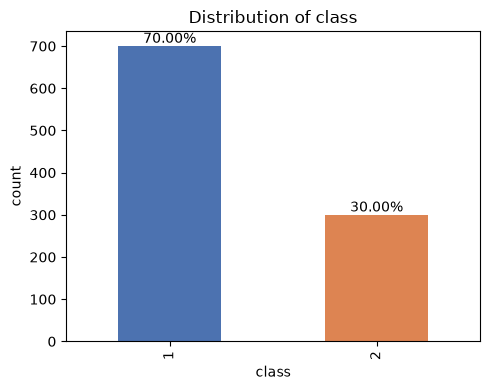

In [9]:
print("unique values:", y.unique())
print("mean:", y.mean())

counts = y.value_counts()
pct = y.value_counts(normalize=True).round(4)
dist = pd.concat([counts, pct], axis=1)
dist.columns = ['count', 'pct']
display(dist)

fig, ax = plt.subplots(figsize=(5, 4))
dist['count'].plot(kind='bar', ax=ax, color=['#4C72B0', '#DD8452'])
for i, (c, p) in enumerate(zip(dist['count'], dist['pct'])):
    ax.text(i, c, f"{p*100:.2f}%", ha='center', va='bottom')
ax.set_title(f"Distribution of {target_col}")

ax.set_ylabel("count")
plt.tight_layout()
plt.show()

# Features distribution

In [10]:
numeric_features = X.select_dtypes(include="number").columns
categorical_features = X.select_dtypes(exclude="number").columns

## Numeric features

In [11]:
decile_table = X[numeric_features].describe(
    percentiles=[.01, .05, .10, .20, .30, .40, .50, .60, .70, .80, .90, .95, .99]
).T

In [12]:
decile_table

,count,mean,std,min,1%,5%,10%,20%,30%,40%,50%,60%,70%,80%,90%,95%,99%,max
duration,1000.0,20.903,12.058814,4.0,6.00,6.00,9.0,12.0,12.0,15.0,18.0,24.0,24.0,30.0,36.0,48.0,60.00,72.0
credit_amount,1000.0,3271.258,2822.736876,250.0,425.83,708.95,932.0,1262.0,1479.4,1906.8,2319.5,2852.4,3590.0,4720.0,7179.4,9162.7,14180.39,18424.0
installment_commitment,1000.0,2.973,1.118715,1.0,1.00,1.00,1.0,2.0,2.0,3.0,3.0,4.0,4.0,4.0,4.0,4.0,4.00,4.0
residence_since,1000.0,2.845,1.103718,1.0,1.00,1.00,1.0,2.0,2.0,2.0,3.0,4.0,4.0,4.0,4.0,4.0,4.00,4.0
age,1000.0,35.546,11.375469,19.0,20.00,22.00,23.0,26.0,28.0,30.0,33.0,36.0,39.0,45.0,52.0,60.0,67.01,75.0
existing_credits,1000.0,1.407,0.577654,1.0,1.00,1.00,1.0,1.0,1.0,1.0,1.0,1.0,2.0,2.0,2.0,2.0,3.00,4.0
num_dependents,1000.0,1.155,0.362086,1.0,1.00,1.00,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,2.0,2.0,2.00,2.0


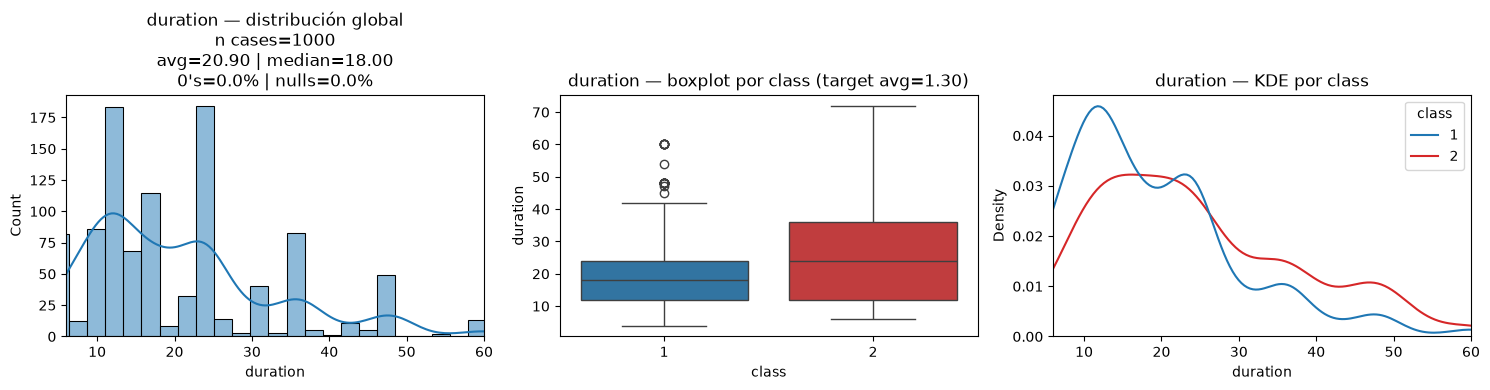

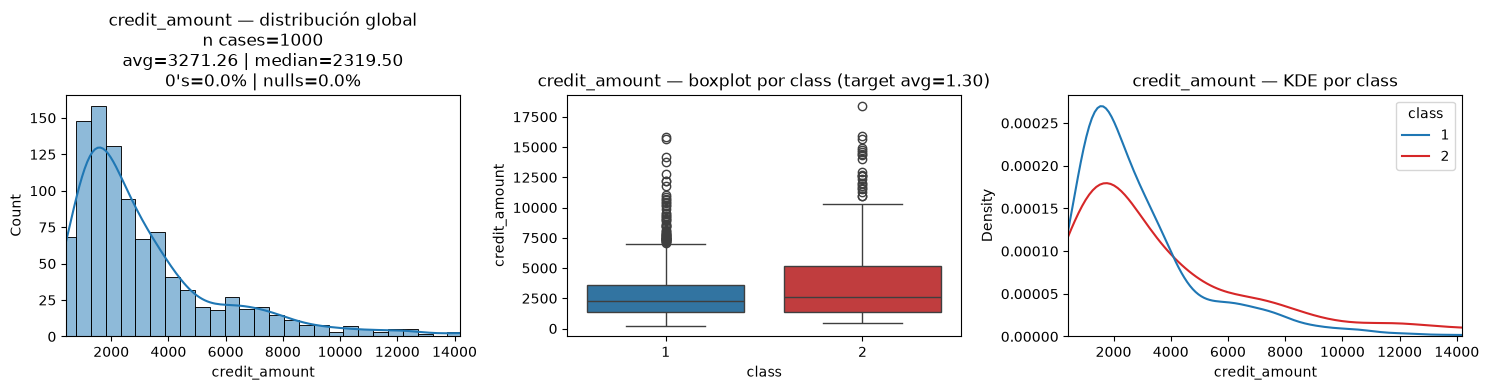

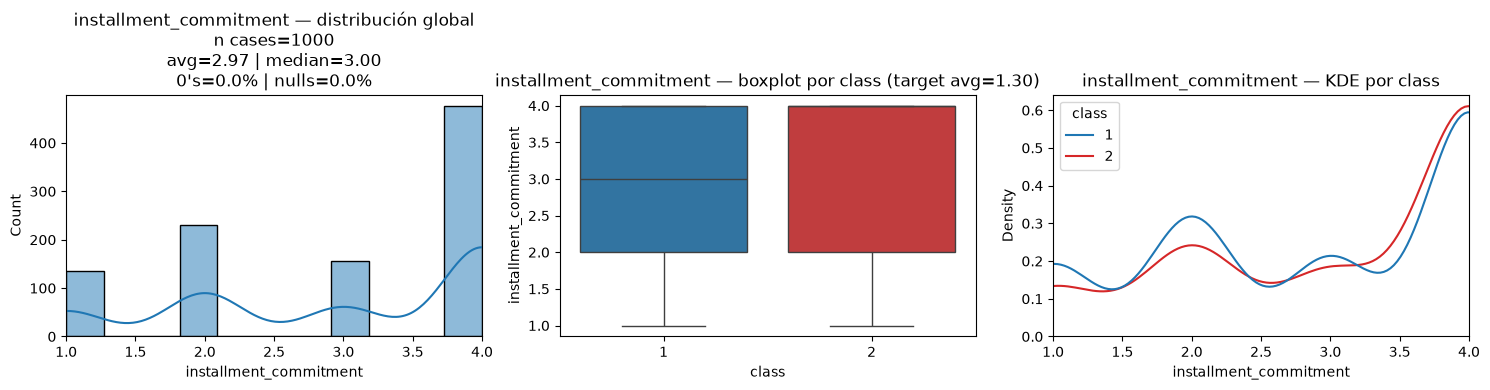

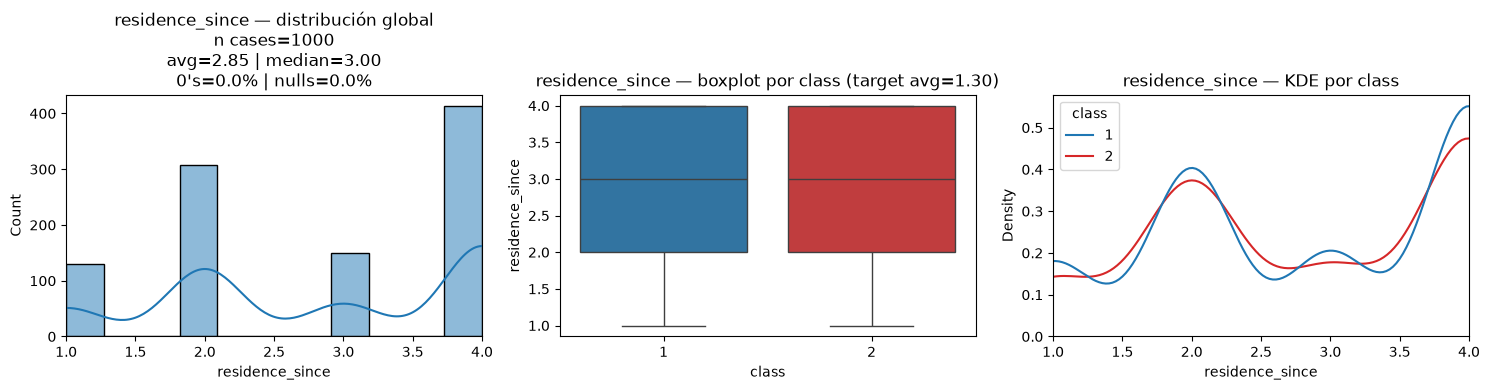

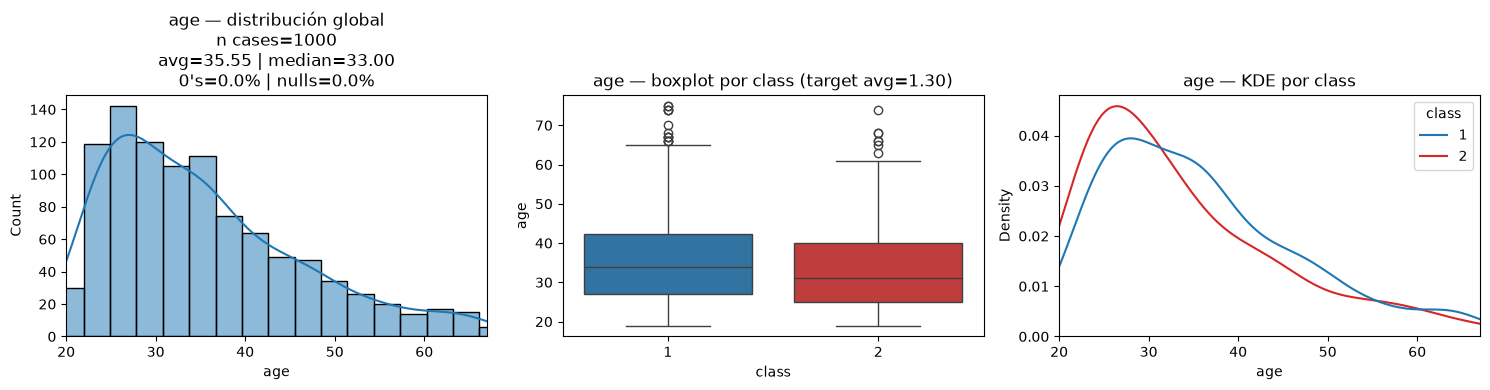

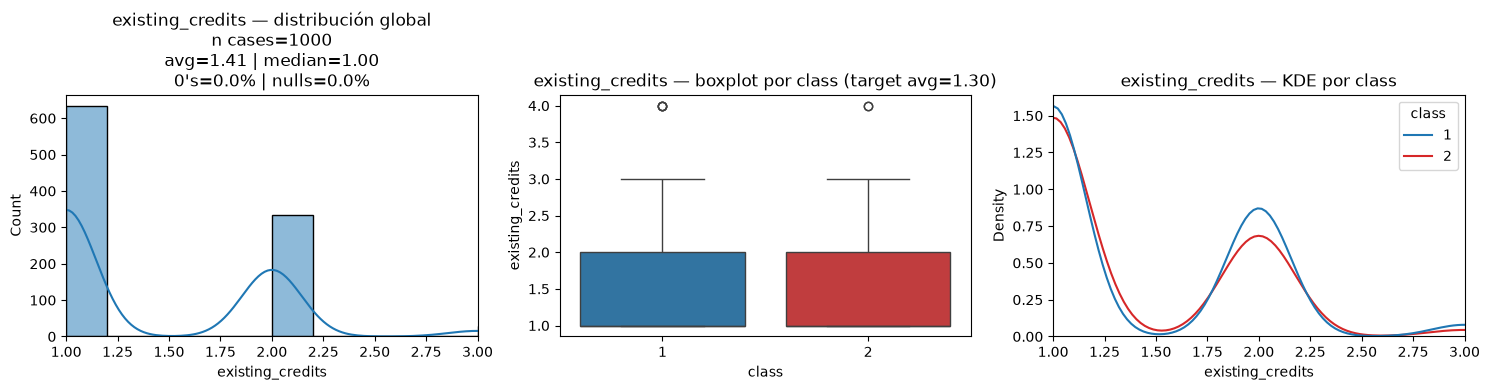

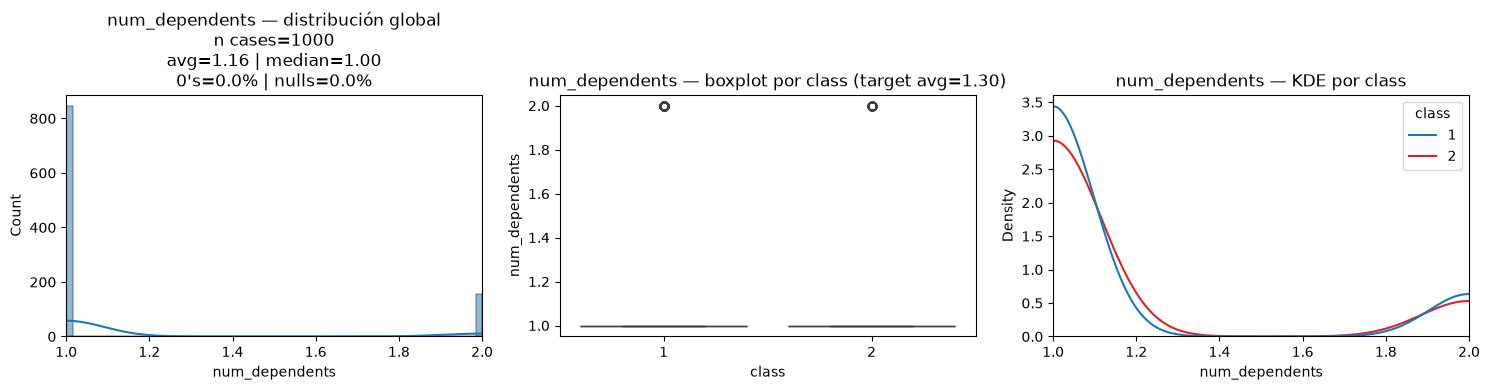

In [14]:
majority_class = y.value_counts().idxmax()
minority_class = y.value_counts().idxmin()
class_palette = {majority_class: "tab:blue", minority_class: "tab:red"}
target_avg = y.mean()

for col in numeric_features:
    p01, p99 = decile_table.loc[col, ["1%", "99%"]]

    n_cases = df[col].notna().sum()
    avg = df[col].mean()
    median = df[col].median()
    pct_zeros = (df[col] == 0).mean()
    pct_nulls = df[col].isna().mean()

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    sns.histplot(data=df, x=col, kde=True, ax=axes[0])
    axes[0].set_xlim(p01, p99)
    axes[0].set_title(
        f"{col} — distribución global\n"
        f"n cases={n_cases}\n" 
        f"avg={avg:.2f} | median={median:.2f}\n"
        f"0's={pct_zeros:.1%} | nulls={pct_nulls:.1%}"
    )

    sns.boxplot(
        x=target_col, y=col, data=df, hue=target_col,
        palette=class_palette, legend=False, ax=axes[1],
    )
    axes[1].set_title(f"{col} — boxplot por {target_col} (target avg={target_avg:.2f})")

    sns.kdeplot(
        data=df, x=col, hue=target_col, common_norm=False,
        palette=class_palette, ax=axes[2],
    )
    axes[2].set_xlim(p01, p99)
    axes[2].set_title(f"{col} — KDE por {target_col}")

    plt.tight_layout()
    plt.show()

## Numeric feature correlations

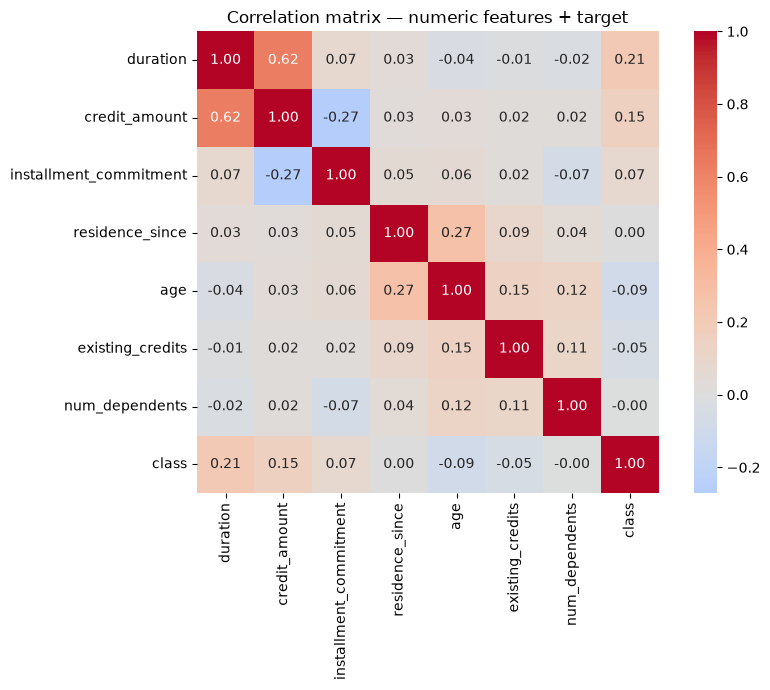

In [13]:
# target_col included as a rough signal only — class is a nominal 1/2 code,
# not a continuous target, so treat its correlations as directional, not exact.
corr = df[list(numeric_features) + [target_col]].corr()

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True, ax=ax)
ax.set_title("Correlation matrix — numeric features + target")
plt.tight_layout()
plt.show()

## Categorical features

In [14]:
# class: 1 = good, 2 = bad credit risk (per UCI docs) -> flatten to a legible rate
target_flag = (y == 2).astype(int)
overall_bad_rate = target_flag.mean()
print(f"Overall bad-credit rate: {overall_bad_rate:.2%}")

Overall bad-credit rate: 30.00%


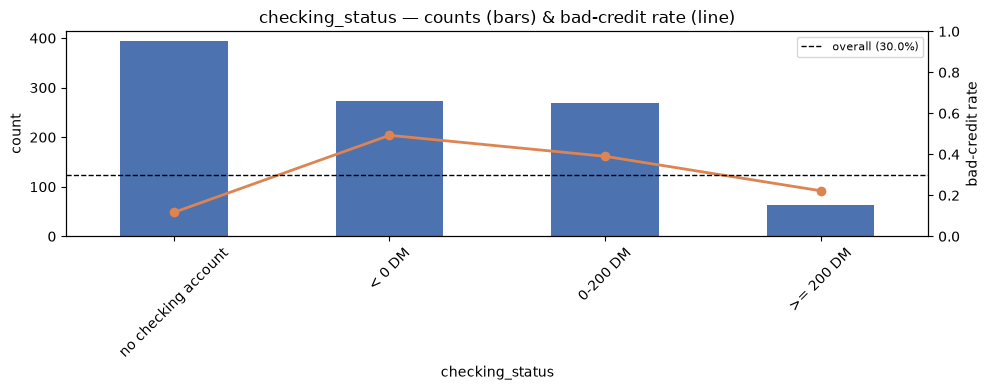

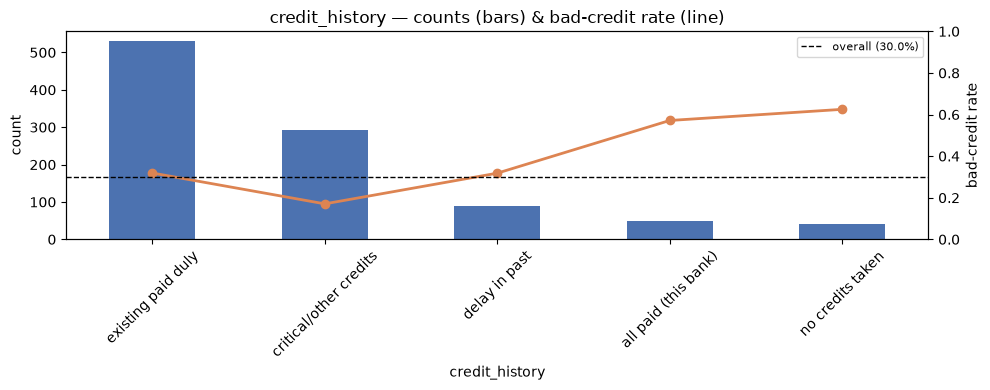

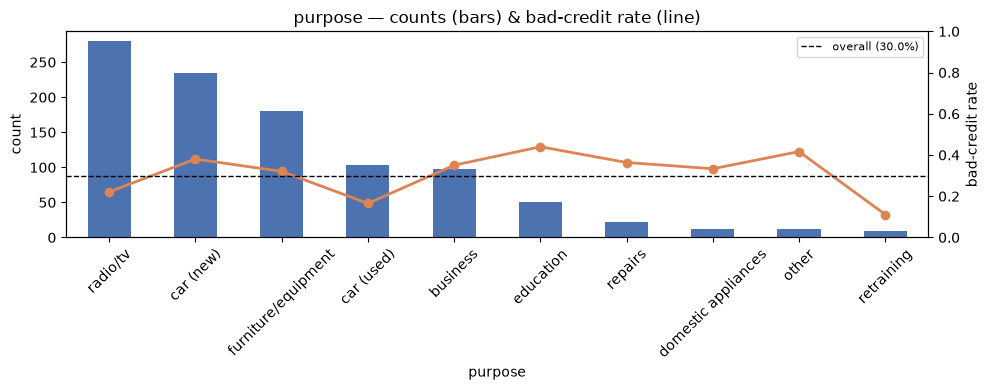

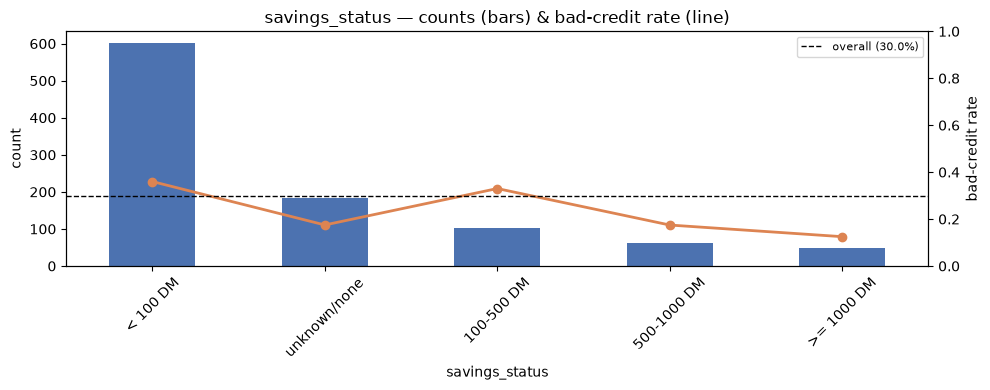

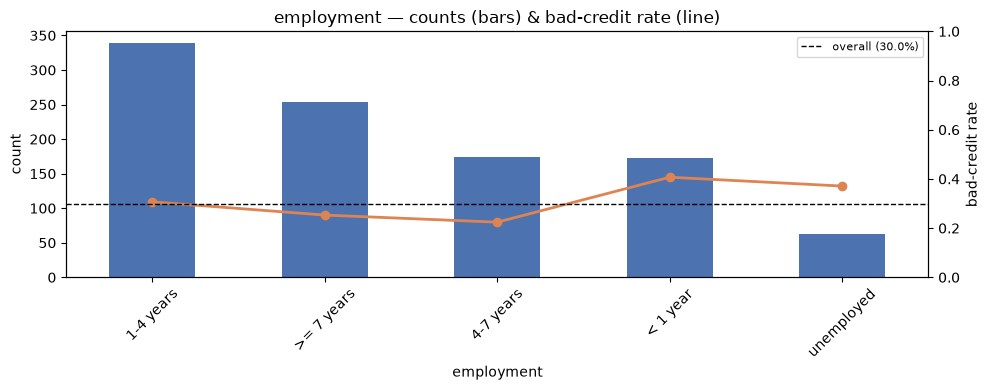

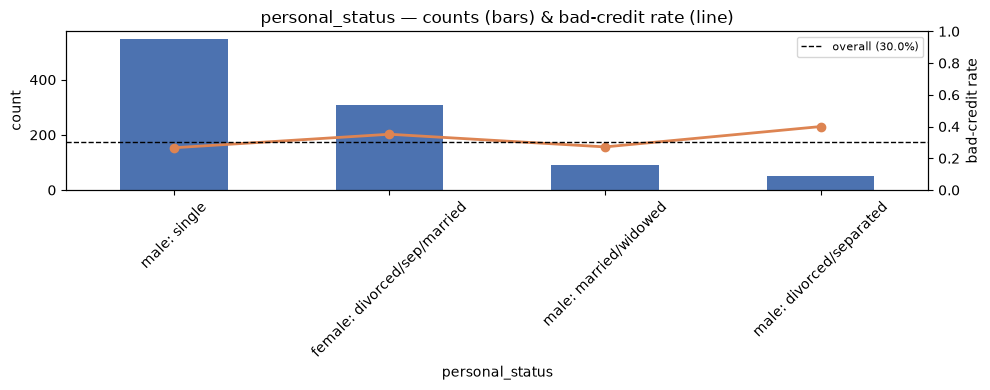

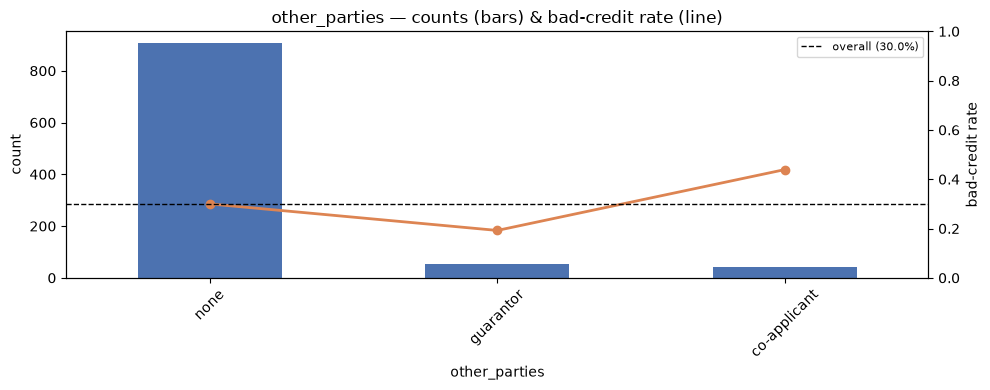

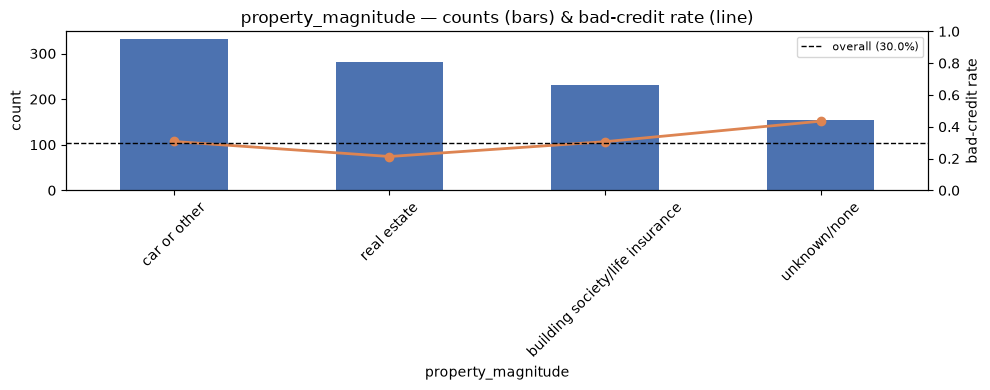

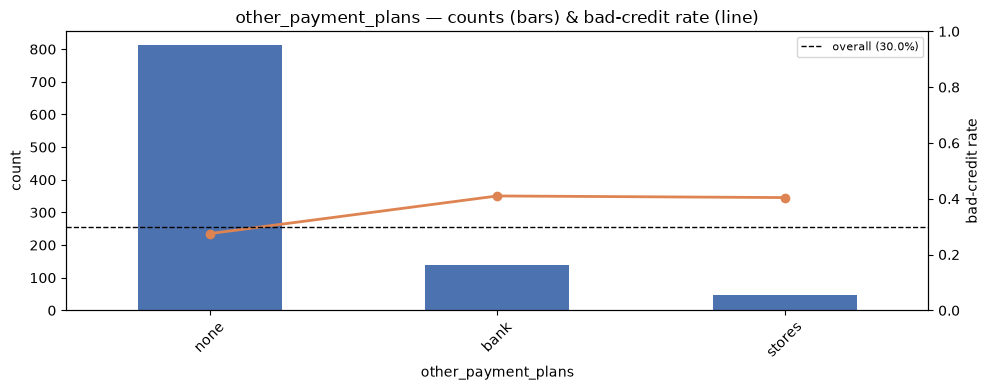

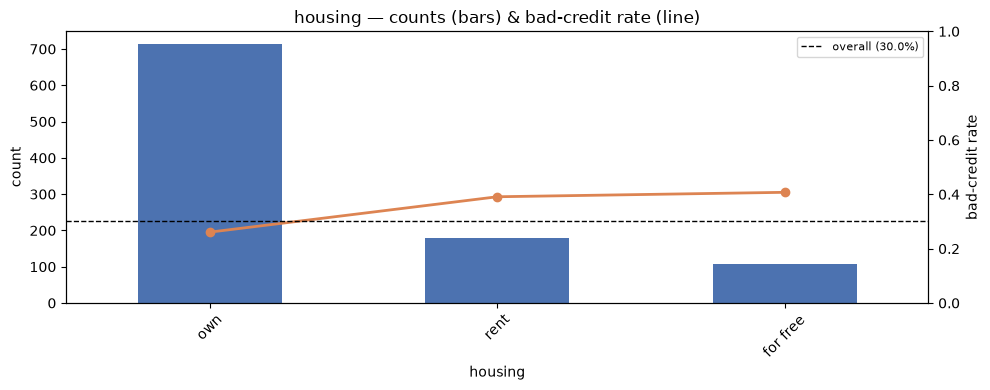

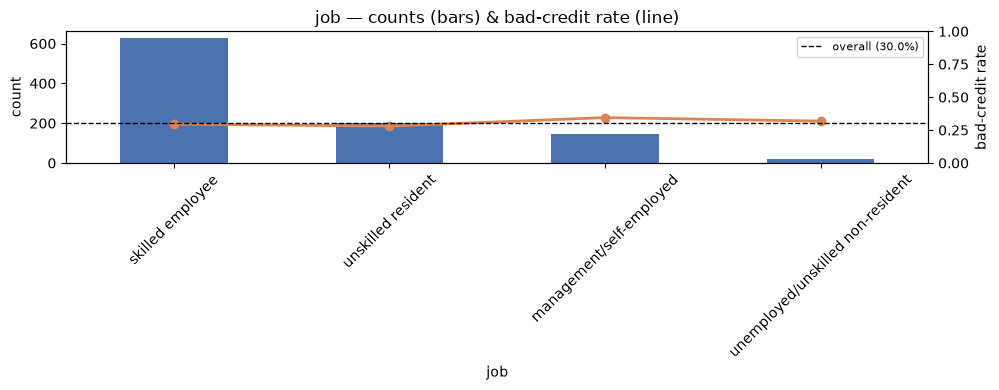

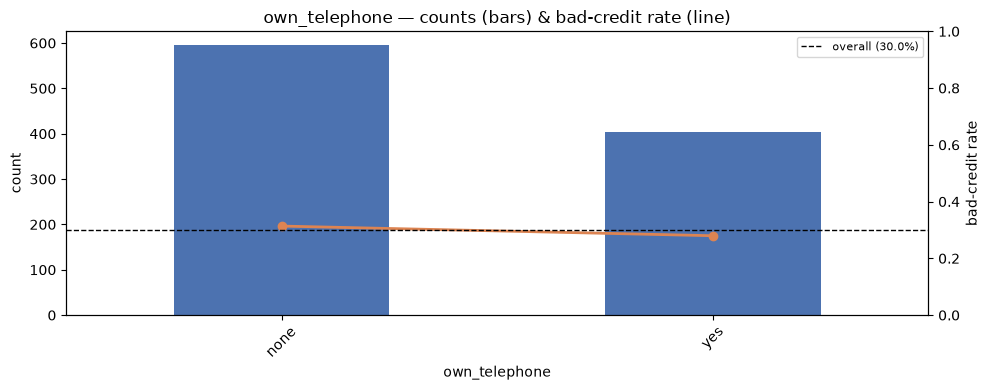

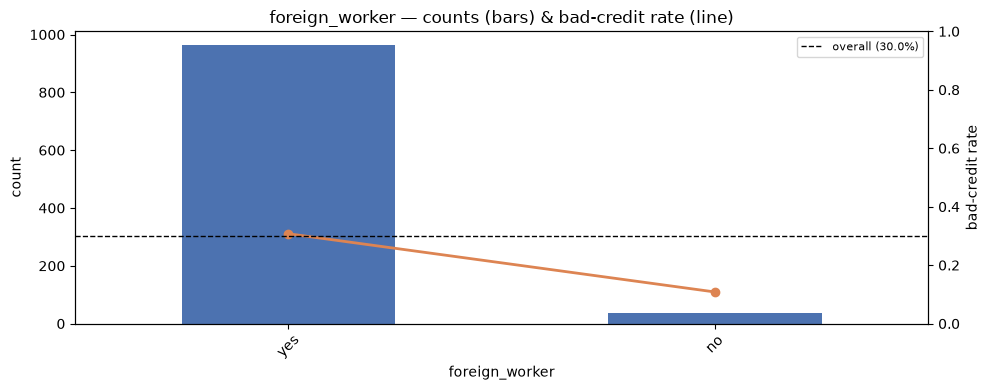

In [15]:
for col in categorical_features:
    counts = X[col].value_counts()
    bad_rate = target_flag.groupby(X[col]).mean().reindex(counts.index)

    fig, ax1 = plt.subplots(figsize=(10, 4))

    counts.plot(kind="bar", ax=ax1, color="#4C72B0")
    ax1.set_ylabel("count")
    ax1.tick_params(axis="x", rotation=45)

    ax2 = ax1.twinx()
    ax2.plot(range(len(bad_rate)), bad_rate.values, color="#DD8452", marker="o", linewidth=2)
    ax2.axhline(overall_bad_rate, color="black", linestyle="--", linewidth=1,
                label=f"overall ({overall_bad_rate:.1%})")
    ax2.set_ylabel("bad-credit rate")
    ax2.set_ylim(0, 1)
    ax2.legend(fontsize=8, loc="upper right")

    ax1.set_title(f"{col} — counts (bars) & bad-credit rate (line)")
    plt.tight_layout()
    plt.show()

### Feature relationships (toolkit showcase)

`plot_exploratory_timeseries` and `plot_category_panels` (also in `visualization.py`) require a date column — not applicable to this dataset, so they're skipped here on purpose.

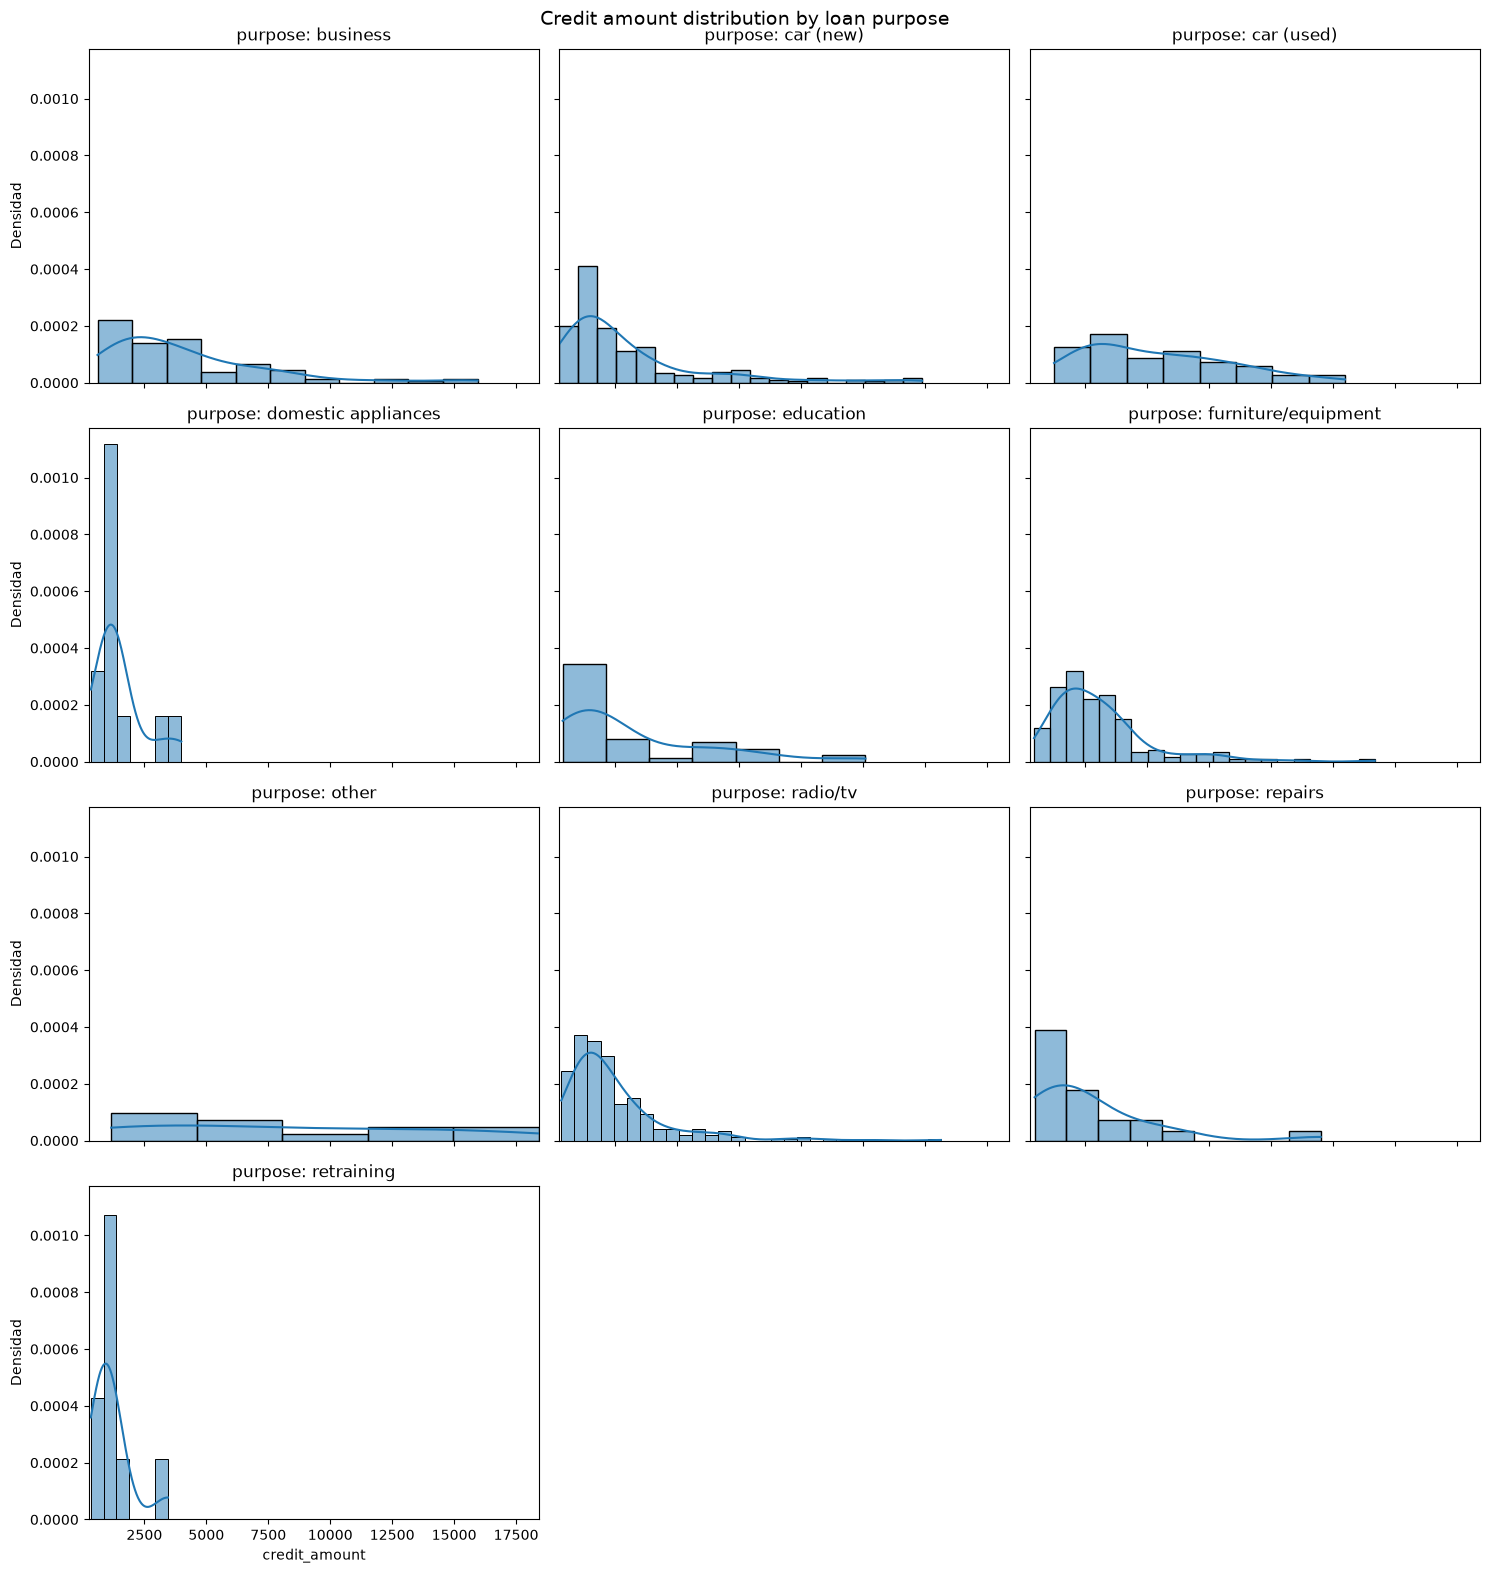

In [16]:
visualization.plot_hist_grid_by_category(
    df=df,
    value_col="credit_amount",
    legend_col="purpose",
    title="Credit amount distribution by loan purpose",
    figsize=(15, 16),
)

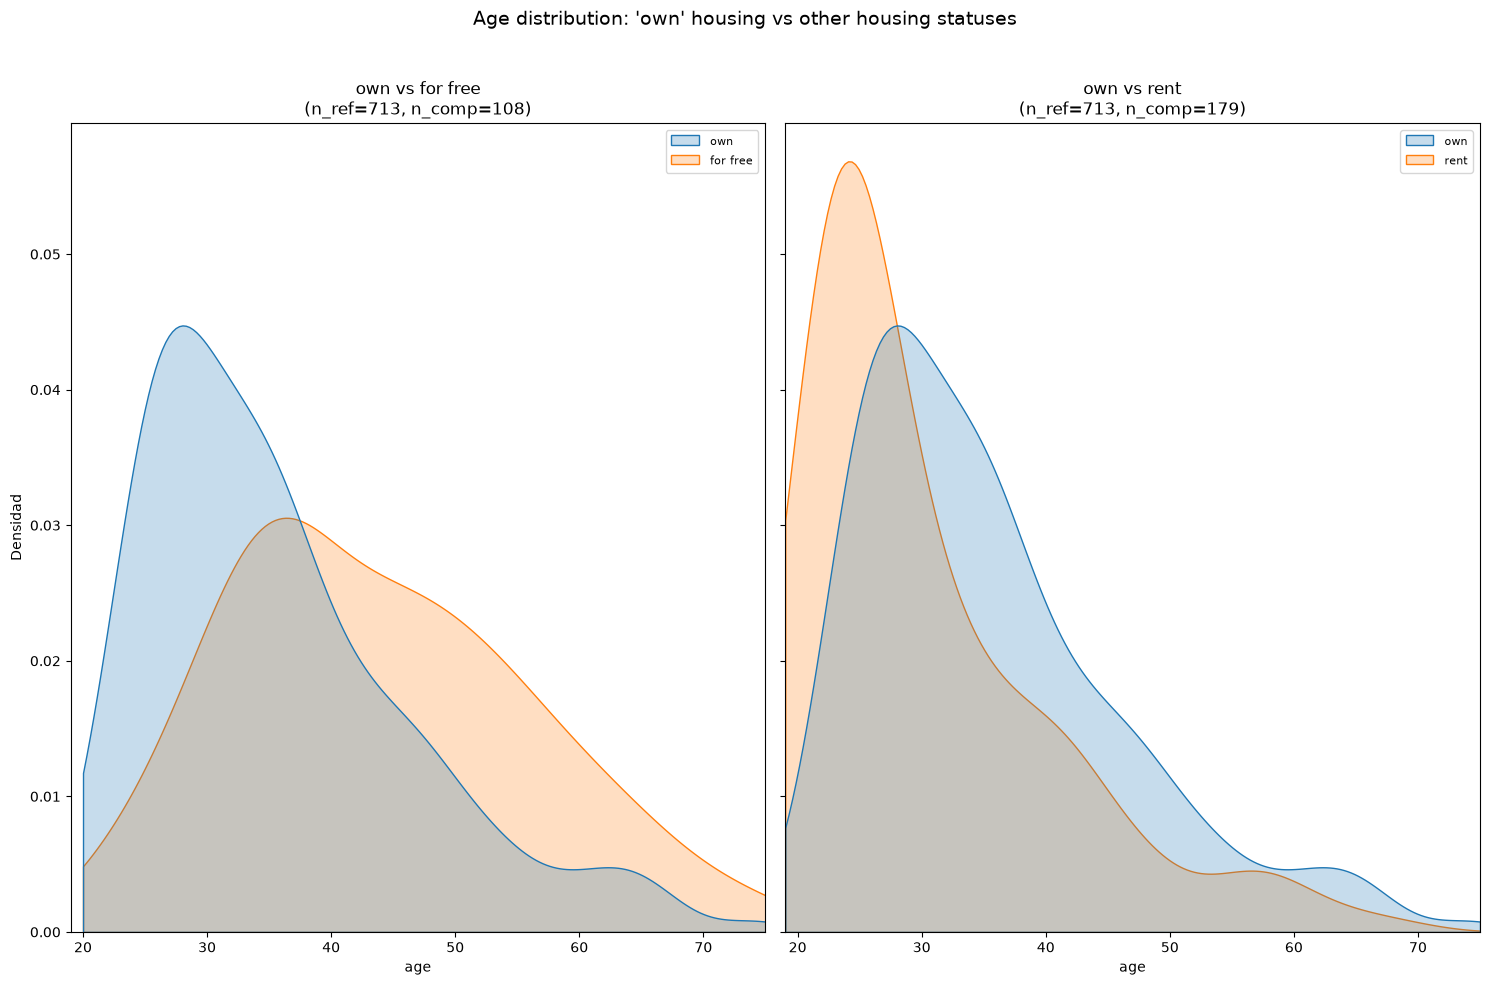

In [17]:
visualization.plot_kde_grid_vs_reference(
    df=df,
    value_col="age",
    legend_col="housing",
    label_name_reference="own",
    title="Age distribution: 'own' housing vs other housing statuses",
    n_cols=2,
)

## Takeaways

- **Class imbalance**: 70% good / 30% bad (`class` 1/2) — the classic UCI split. Plain accuracy will be misleading; use a metric that accounts for imbalance.
- **Numeric features**: `duration` (corr ≈ 0.22) and `credit_amount` (corr ≈ 0.16) are the most associated with bad credit — longer, larger loans skew riskier. `age` has a mild negative association (≈ -0.09, older applicants slightly safer). `num_dependents` and `residence_since` are essentially uninformative (corr ≈ 0).
- **Categorical features**: `credit_history` and `checking_status` show by far the largest bad-rate swings across categories (spreads of 0.45 and 0.38) — the most informative categorical features. `own_telephone` and `job` are nearly flat (spread < 0.07) — little signal.
- **Counter-intuitive standout**: bad rate by `checking_status` ranges from 49% (`< 0 DM`) down to just 12% (`no checking account`) — having no checking account at all is *safer* than a negative balance, likely a quirk of who ends up with no account at all in this sample.
- **Cross-checks**: `credit_amount` varies a lot by `purpose` (mean ~$8.2k for "other" vs ~$1.2k for "retraining"); `age` shifts meaningfully by `housing` (~44 for "for free" vs ~30 for "rent").
- Any of the above worth acting on should graduate out of this playground notebook into a proper ADR/research report, not stay here.